# Paramétrage de l'environnement de travail et import des packages

In [11]:
import sys
from pathlib import Path

In [12]:
ROOT = Path.cwd().parents[0]

RAW_DATA = ROOT / "01_data" / "01_raw"
PROCESSED_DATA = ROOT / "01_data" / "02_processed"
JOBLIB_DATA = ROOT / "01_data" / "03_joblib"
MODEL_DATA = ROOT / "04_model"

%load_ext autoreload
%autoreload 2
sys.path.append(str(ROOT / "03_fonctions"))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [37]:
import pandas as pd
import numpy as np
from fonctions_perso.data_manipulation import multi_astype

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector

from xgboost import XGBClassifier

from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from scipy.stats import randint, uniform, loguniform
from sklearn.calibration import CalibratedClassifierCV

from fonctions_perso.machine_learning import IsolationForestCustom
from sklearn.preprocessing import OneHotEncoder

import seaborn as sns
import matplotlib.pyplot as plt
from fonctions_perso.machine_learning import ThresholdCostOptimizer, BinaryMetricsSimple, graphique_courbe_pr, graphique_courbe_calibration
from fonctions_perso.data_manipulation import stratified_sample

from sklearn import set_config
set_config(transform_output="pandas")

import joblib
import shap


# La base de données

In [14]:
data_fraud = pd.read_parquet(PROCESSED_DATA / "data_fraud_eda_processed.parquet").reset_index(drop = True)

In [15]:
values_etats_client = data_fraud["etat_client"].value_counts().reset_index()["etat_client"]

In [16]:
multi_astype(
    data_fraud,
    ["type_magasin","etat_client","heure_transaction"],
    "string"
)

type_magasin: object → string
etat_client: object → string
heure_transaction: int32 → string

Succès: 3/3


**Informations globales**

In [137]:
data_fraud.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 20 columns):
 #   Column                     Dtype         
---  ------                     -----         
 0   date_heure_transaction     datetime64[ns]
 1   nom_magasin                object        
 2   type_magasin               string        
 3   montant_transaction        float64       
 4   ville_client               object        
 5   etat_client                string        
 6   latitude_domicile_client   float64       
 7   longitude_domicile_client  float64       
 8   population_ville_client    int64         
 9   profession_client          object        
 10  numero_transaction         object        
 11  latitude_magasin           float64       
 12  longitude_magasin          float64       
 13  target                     int64         
 14  annee_transaction          int32         
 15  mois_transaction           object        
 16  jour_transaction           object   

**Statistiques descriptives**

In [138]:
data_fraud.describe()

,date_heure_transaction,montant_transaction,latitude_domicile_client,longitude_domicile_client,population_ville_client,latitude_magasin,longitude_magasin,target,annee_transaction,distance_domicile_magasin,age_client
count,1852394,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06
mean,2020-01-20 21:31:46.801825536,7.006357e+01,3.853931e+01,-9.022783e+01,8.864367e+04,3.853898e+01,-9.022794e+01,5.210015e-03,2.019501e+03,7.611183e+01,4.621138e+01
min,2019-01-01 00:00:18,1.000000e+00,2.002710e+01,-1.656723e+02,2.300000e+01,1.902742e+01,-1.666716e+02,0.000000e+00,2.019000e+03,2.225455e-02,1.400000e+01
25%,2019-07-23 04:13:43.750000128,9.640000e+00,3.466890e+01,-9.679800e+01,7.410000e+02,3.474012e+01,-9.689944e+01,0.000000e+00,2.019000e+03,5.532016e+01,3.300000e+01
50%,2020-01-02 01:15:31,4.745000e+01,3.935430e+01,-8.747690e+01,2.443000e+03,3.936890e+01,-8.744069e+01,0.000000e+00,2.020000e+03,7.821649e+01,4.400000e+01
75%,2020-07-23 12:11:25.249999872,8.310000e+01,4.194040e+01,-8.015800e+01,2.032800e+04,4.195626e+01,-8.024511e+01,0.000000e+00,2.020000e+03,9.850960e+01,5.700000e+01
max,2020-12-31 23:59:34,2.894890e+04,6.669330e+01,-6.795030e+01,2.906700e+06,6.751027e+01,-6.695090e+01,1.000000e+00,2.020000e+03,1.521174e+02,9.600000e+01
std,NaN,1.592540e+02,5.071470e+00,1.374789e+01,3.014876e+05,5.105604e+00,1.375969e+01,7.199217e-02,4.999996e-01,2.911701e+01,1.739545e+01


**Aperçu rapide des données**

In [139]:
data_fraud.head()

,date_heure_transaction,nom_magasin,type_magasin,montant_transaction,ville_client,etat_client,latitude_domicile_client,longitude_domicile_client,population_ville_client,profession_client,numero_transaction,latitude_magasin,longitude_magasin,target,annee_transaction,mois_transaction,jour_transaction,heure_transaction,distance_domicile_magasin,age_client
0,2020-06-21 12:14:25,Kirlin and Sons,personal_care,2.86,Columbia,SC,33.9659,-80.9355,333497,Mechanical engineer,2da90c7d74bd46a0caf3777415b3ebd3,33.986391,-81.200714,0,2020,June,Sunday,12,24.561496,52
1,2020-06-21 12:14:33,Sporer-Keebler,personal_care,29.84,Altonah,UT,40.3207,-110.4360,302,"Sales professional, IT",324cc204407e99f51b0d6ca0055005e7,39.450498,-109.960431,0,2020,June,Sunday,12,104.925237,30
2,2020-06-21 12:14:53,"Swaniawski, Nitzsche and Welch",health_fitness,41.28,Bellmore,NY,40.6729,-73.5365,34496,"Librarian, public",c81755dbbbea9d5c77f094348a7579be,40.495810,-74.196111,0,2020,June,Sunday,12,59.080159,50
3,2020-06-21 12:15:15,Haley Group,misc_pos,60.05,Titusville,FL,28.5697,-80.8191,54767,Set designer,2159175b9efe66dc301f149d3d5abf8c,28.812398,-80.883061,0,2020,June,Sunday,12,27.698606,33
4,2020-06-21 12:15:17,Johnston-Casper,travel,3.19,Falmouth,MI,44.2529,-85.0170,1126,Furniture designer,57ff021bd3f328f8738bb535c302a31b,44.959148,-85.884734,0,2020,June,Sunday,12,104.335250,65


# Machine Learning

**Construction de l'échantillon train | validation | test**

In [17]:
variables_a_retirer = ["target","nom_magasin","ville_client","profession_client","numero_transaction",
                       "annee_transaction","latitude_domicile_client","longitude_domicile_client",
                       "latitude_magasin","longitude_magasin","mois_transaction","jour_transaction","population_ville_client",
                       "distance_domicile_magasin","date_heure_transaction"]

periode_validation = ["January","February","March","April","May","June","July","August","September"]

# X/Y Train trié par ordre de transaction pour préparer la validation croisée temporelle (TimeSeriesSplit)
train_2019 = data_fraud[data_fraud["annee_transaction"]==2019].sort_values(by="date_heure_transaction").reset_index(drop=True)

x_train = train_2019.drop(variables_a_retirer, axis = 1)
y_train = train_2019["target"]


# Test & Validation
data_fraud_2020_validation = (data_fraud[(data_fraud["annee_transaction"]==2020) & (data_fraud["mois_transaction"].isin(periode_validation))]
                              .sort_values(by="date_heure_transaction")
                              .reset_index(drop=True))

data_fraud_2020_test = (data_fraud[(data_fraud["annee_transaction"]==2020) & (~data_fraud["mois_transaction"].isin(periode_validation))]
                        .sort_values(by="date_heure_transaction")
                        .reset_index(drop=True))


    # --- Validation
x_validation = data_fraud_2020_validation.drop(variables_a_retirer, axis=1)
y_validation = data_fraud_2020_validation["target"]

    # --- Test
x_test = data_fraud_2020_test.drop(variables_a_retirer, axis=1)
y_test = data_fraud_2020_test["target"]


In [18]:
# Taux de transactions frauduleuses sur l'échantillon train
data_fraud[data_fraud["annee_transaction"]==2019]["target"].mean()

0.005644158512191166

In [19]:
# Taux de transactions frauduleuses sur l'échantillon de validation pour la recherche du seuil
data_fraud_2020_validation["target"].mean()

0.005410024101309086

In [20]:
# Taux de transactions frauduleuses sur l'échantillon test
data_fraud_2020_test["target"].mean()

0.003324796373982758

**Création de la pipeline**

In [21]:
# Preprocessing
    # -- Encodage des variables catégorielles 
var_cat_pipe = Pipeline([
    ("one_hot_encoder", OneHotEncoder(drop=None, sparse_output=False, handle_unknown='ignore'))
])

    # -- Isolation Forest sur les données et création de la variable "if_score"
all_var_pipe = Pipeline([
    ("isolation_forest", IsolationForestCustom(
        n_estimators=100,        
        max_samples="auto",      
        contamination="auto",    
        max_features=1.0,        
        bootstrap=False,         
        n_jobs=-1,               
        random_state=1,         
        verbose=0,               
        warm_start=False         
    ))
])


# XGBoost (Objectif : Stabilité)
    # -- Modèle de base
xgb = XGBClassifier(
    scale_pos_weight=200, # 0.995/0.005 (Taux de tranaction frauduleuses en train)
    random_state=1,
    n_jobs=-1
)

    # -- Préparation des hyperparamètres à tuner
hyperparametres = {
    "model__n_estimators": randint(50, 200),
    "model__max_depth": randint(3, 6),
    
        # --- Apprentissage lent (0.01 - 0.05)
    "model__learning_rate": loguniform(0.01, 0.05),
    
        # --- Bagging et Feature sampling forts
    "model__subsample": uniform(0.5, 0.3),        
    "model__colsample_bytree": uniform(0.5, 0.3), 
    
        # --- Régularisation forte sur les feuilles
    "model__min_child_weight": randint(5, 10),
    
        # --- Réduction de perte minimale pour splitter
    "model__gamma": loguniform(0.01, 0.5), 
    
        # --- Régularisation L1 et L2 (Forte)
    "model__reg_alpha": loguniform(0.1, 1.0),
    "model__reg_lambda": loguniform(1.0, 10.0)
}

In [22]:
# Assemblage 
preprocessing_1 = ColumnTransformer([
    ("one_hot_encoding", var_cat_pipe, make_column_selector(dtype_exclude=np.number))
], remainder="passthrough")

pipeline_complete = Pipeline([
    ("ohe", preprocessing_1),
    ("isolation_forest", all_var_pipe),
    ("model", xgb)
])

In [114]:
# Tuning des hyperparamètres
tscv = TimeSeriesSplit(n_splits=4)

recherche = RandomizedSearchCV(
    estimator = pipeline_complete,
    param_distributions = hyperparametres,
    n_iter = 6,
    scoring = "neg_brier_score",
    cv = tscv,  
    return_train_score = True,
    refit = True,
    random_state = 1,
    n_jobs = -1,
    error_score = "raise",
)

_ = recherche.fit(x_train, y_train)
modele = recherche.best_estimator_

In [115]:
# Calibration des probabilités
modele_propre = CalibratedClassifierCV(
    estimator = modele,  
    method = 'isotonic',       
    cv = 5                    
)

_ = modele_propre.fit(x_train, y_train)

In [ ]:
#modele = joblib.load(MODEL_DATA / "fraud_detection_xgb_pas_calibre.joblib")
#modele_propre = joblib.load(MODEL_DATA / "fraud_detection_model_xgboost.joblib")

**Recherche du seuil de probabilité optimal à partir de l'échantillon 'validation'**

In [25]:
# Entrainement (Echantillon validation)
y_validation_proba = modele_propre.predict_proba(x_validation)[:,1]

<Axes: title={'center': 'Répartition des probabilités (Echantillon validation)'}, xlabel='Probabilités', ylabel='Nombre'>

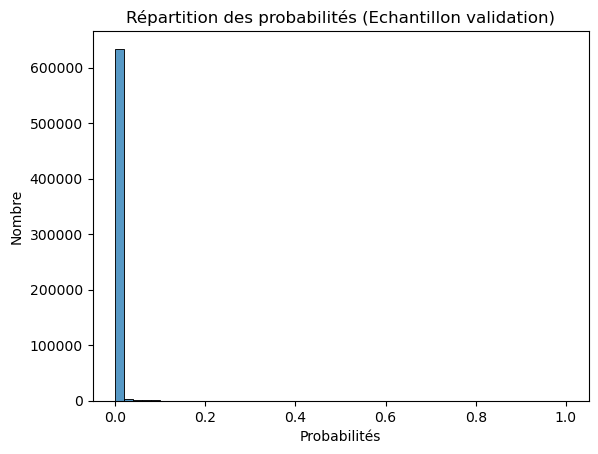

In [26]:
# Répartition des probabilités (Echantillon validation)
df_y_validation_proba = pd.DataFrame(y_validation_proba)
df_y_validation_proba = df_y_validation_proba.rename(columns={0:"proba"})

plt.title("Répartition des probabilités (Echantillon validation)")
plt.xlabel("Probabilités")
plt.ylabel("Nombre")

sns.histplot(
    df_y_validation_proba,
    x="proba",
    bins=50
)

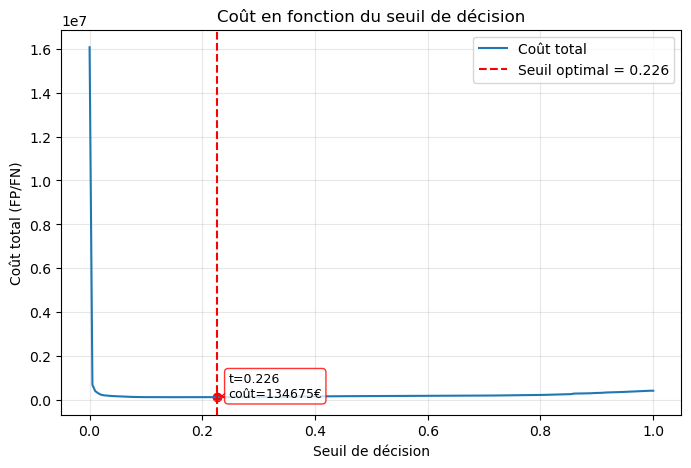

Meilleur seuil : 0.226 | Coût minimal : 134675.00€


In [42]:
# Recherche du seuil permettant de minimiser les couts à partir de l'échantillon "validation"
cost_optimizer = ThresholdCostOptimizer(cost_fp=25, cost_fn=125, n_thresholds=200)

cost_optimizer.fit(y_validation, y_validation_proba)

cost_optimizer.plot_cost_curve()

In [ ]:
cost_optimizer_artifacts = {
    "seuils": cost_optimizer.seuils_,
    "costs": cost_optimizer.costs_,
    "best_threshold": cost_optimizer.get_best_threshold(),
    "best_cost": cost_optimizer.get_best_cost()
}

**Entrainement du modèle sur l'échantillon 'train' et 'test'**

In [28]:
# Train
train_proba = modele_propre.predict_proba(x_train)[:,1]
train_pred = (train_proba >= cost_optimizer.get_best_threshold()).astype(int)

# Test
test_proba = modele_propre.predict_proba(x_test)[:,1]
test_pred = (test_proba >= cost_optimizer.get_best_threshold()).astype(int)

**Sauvegarde des données**

In [29]:
full_test = pd.concat([x_test,y_test], axis = 1)

full_test_sample = stratified_sample(
    df=full_test,
    target="target",
    n=35000,
    random_state=123
)

x_test_sample = full_test_sample.drop(["target"], axis = 1)

In [50]:
# Modèles 
joblib.dump(modele, MODEL_DATA / "fraud_detection_xgb_pas_calibre.joblib")  
joblib.dump(modele_propre, MODEL_DATA / "fraud_detection_model_xgboost.joblib") 

# Train
joblib.dump(y_train, JOBLIB_DATA / "y_train.joblib")
joblib.dump(train_proba, JOBLIB_DATA / "train_proba.joblib")

# Validation
joblib.dump(data_fraud_2020_validation["target"], JOBLIB_DATA / "y_validation.joblib")
joblib.dump(df_y_validation_proba, JOBLIB_DATA / "proba_validation.joblib")

# Test complet
joblib.dump(y_test, JOBLIB_DATA / "y_test.joblib")
joblib.dump(test_proba, JOBLIB_DATA / "test_proba.joblib")

# Objets CostOptimizer contenant le seuil optimal
joblib.dump(cost_optimizer, JOBLIB_DATA / "cost_optimizer.joblib")
joblib.dump(cost_optimizer_artifacts, JOBLIB_DATA / "cost_optimizer_artifacts.joblib")

# Liste des modalités de la variable "etat_client"
joblib.dump(list(values_etats_client), JOBLIB_DATA / "values_etat_client.joblib")

# Echantillons de données pour l'onglet 3 de l'application Streamlit
fraud_1 = full_test[full_test["target"]==1].sample(5)
fraud_0 = full_test[full_test["target"]==0].sample(5)

test_sample_onglet_3 = pd.concat([fraud_0,fraud_1], axis=0).sample(10)
joblib.dump(test_sample_onglet_3, JOBLIB_DATA / "test_sample_onglet_3.joblib")

['c:\\Users\\user\\Desktop\\data_science_documents\\data_science_projets_perso\\projet_fraud_detection\\fraud-detection\\01_data\\03_joblib\\test_sample_onglet_3.joblib']

**Création et sauvegarde des objets pour l'analyse SHAP**

In [38]:
set_config(transform_output="pandas")

In [39]:
# Echantillon de données "x_test_sample"
joblib.dump(x_test_sample, JOBLIB_DATA / "x_test_sample.joblib")


x_test_proc = modele[:-1].transform(x_test_sample) # x_test_sample avec preprocessing uniquement (sans le modèle)
xgb = modele.named_steps["model"]                  # juste le modèle sans les étapes de preprocessing


explainer = shap.TreeExplainer(xgb, x_test_proc) # Initialisation de l'explainer
shap_values = explainer(x_test_proc)             # SHAP Values

# Sauvegarde de l'explainer et des SHAP Values + x_test_processed
joblib.dump(x_test_proc, JOBLIB_DATA / "x_test_processed.joblib")
joblib.dump(explainer, JOBLIB_DATA / "explainer.joblib")
joblib.dump(shap_values, JOBLIB_DATA / "shap_values_modele.joblib")

# Sauvegarde de full_test_sample
joblib.dump(full_test_sample, JOBLIB_DATA / "full_test_sample.joblib")

100%|===================| 34938/34999 [01:37<00:00]        

['c:\\Users\\user\\Desktop\\data_science_documents\\data_science_projets_perso\\projet_fraud_detection\\fraud-detection\\01_data\\03_joblib\\shap_values_modele.joblib']

# Analyse des performances du modèle

In [32]:
performances_modele = BinaryMetricsSimple(
    y_test, test_pred, test_proba
)

**Métriques**

In [33]:
performances_modele.get_metrics_df() # Métriques principales

,Metrique,Valeur
0,accuracy,0.9968
1,precision,0.5133
2,recall,0.7853
3,f1,0.6208
4,mcc,0.6334
5,roc_auc,0.9917
6,brier_score,0.0016
7,average_precision,0.7228


In [34]:
performances_modele.print_confusion_matrix() # Matrice de confusion

MATRICE DE CONFUSION
                      Prédit Négatif | Prédit Positif
Réel Négatif              279888 |            697
Réel Positif                 201 |            735


**Courbe Précision-Rappel**


RÉSULTATS PRÉCISION-RAPPEL
AP Train     : 0.7934
AP Test      : 0.7228
Écart        : 0.0706
Baseline     : 0.0033
⚠️  Attention : écart élevé (possible overfitting)
Lift vs baseline : 217.39x


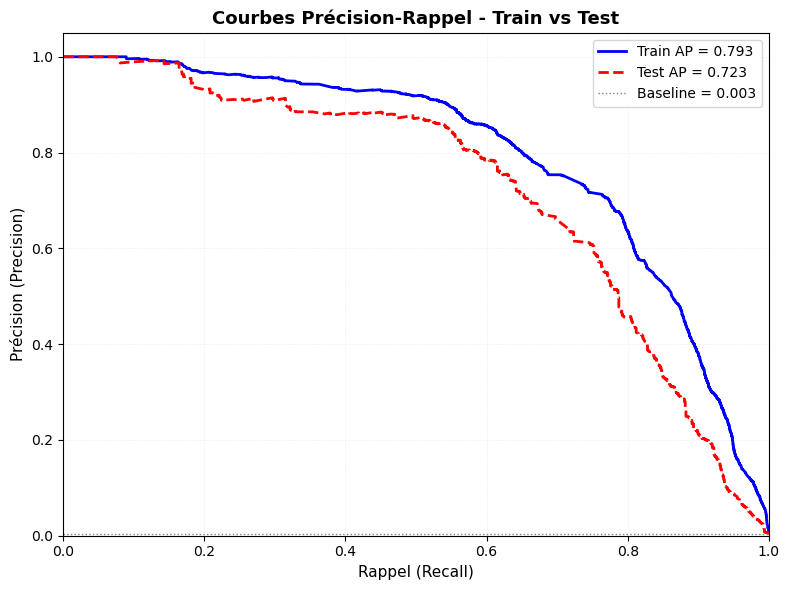

In [35]:
graphique_courbe_pr(
    y_train, train_proba,
    y_test, test_proba
)

**Courbe de calibration**


RÉSULTATS DE CALIBRATION
Brier Score Train : 0.0022
Brier Score Test  : 0.0016
Écart Brier       : 0.0006

ECE Train         : 0.0525
ECE Test          : 0.0784

---------------------------------------------
INTERPRÉTATION :
✓ Excellente calibration (Brier < 0.1)
⚠️  Erreur de calibration modérée (ECE < 0.1)


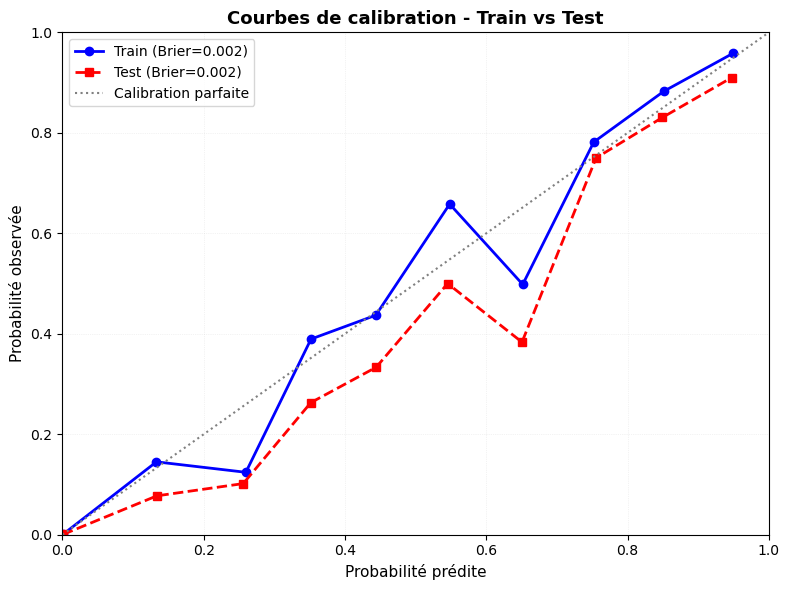

In [36]:
graphique_courbe_calibration(
    y_train, train_proba,
    y_test, test_proba
)

# Note explicative du Notebook

Afin de se rapprocher d’une logique de détection en temps réel, le découpage retenu est strictement chronologique :

- **Train** : données 2019  
- **Validation (recherche du seuil)** : janvier 2020 - septembre 2020  
- **Test final** : octobre 2020 - décembre 2020  

Ce protocole permet de simuler un cadre opérationnel réaliste :  
le modèle est entraîné sur l’historique, le seuil est calibré sur des données plus récentes, puis évalué sur une période ultérieure totalement hors échantillon.

---

## 2. Hypothèse économique

Le seuil de décision est optimisé à partir de la fonction de coût suivante :

> Coût total = 25 × Nombre de faux positifs + 125 × Nombre de faux négatifs  

- Faux positif : **25 €**  
- Faux négatif : **125 €**  

Une fraude non détectée est donc considérée comme **5 fois plus coûteuse** qu’une alerte injustifiée.

---

## 3. Drift observé

Évolution du taux de fraude selon les périodes :

- **Train (2019)** : 0,056 %  
- **Validation (jan-sept 2020)** : 0,054 %  
- **Test (oct-déc 2020)** : 0,033 %  

On observe une baisse du taux de fraude sur la période de test.

Le seuil optimisé sur la validation (régime autour de 0,05 %) devient donc relativement plus permissif lorsqu’il est appliqué au test (régime autour de 0,03 %), ce qui entraîne mécaniquement :

- un **rappel élevé**
- une **baisse de la précision**

---

## 4. Résultats sur l’échantillon test (oct-déc 2020)

### 4.1 Seuil retenu

- **Seuil utilisé** : 0,226  
- **Coût total estimé** : 134 675 €  

### 4.2 Matrice de confusion

- TP = 735  
- FN = 201  
- FP = 740  
- TN = 279 781  

- Fraudes réelles : 936  
- Alertes totales : 1 475  

### 4.3 Indicateurs de performance

- **Fraud Capture Rate (Recall)** : 78,5 %  
  - 735 fraudes détectées sur 936  
- **Fraud Loss Rate** : 21,5 %  
- **Précision** : 51,3 %  
  - environ 1 alerte sur 2 correspond à une fraude réelle  
- **Alert Rate** : 0,51 % des transactions envoyées en alerte  
- **False Positive Rate (FPR)** : 0,24 %  
- **Ratio FP / TP** : 1  
  - environ 1 faux positif pour 1 vrai positif  
- **ROC-AUC** : 0,99  
- **Average Precision (test)** : ≈ 0,72  
- **Brier Score** : très faible  

---

## 5. Interprétation

### 5.1 Pouvoir discriminant

L’AUC proche de 0,99 confirme une excellente capacité du modèle à distinguer les transactions frauduleuses des transactions légitimes.  

Il n’y a pas de dégradation majeure des performances entre train et test, ce qui suggère que le modèle ne souffre pas d’un surapprentissage important.

### 5.2 Effet du drift de prévalence

La baisse du taux de fraude sur la période test explique :

- la baisse de la précision  
- l’écart d’Average Precision entre train et test  

Cet écart est principalement lié au changement de prévalence et non à une instabilité du modèle.

### 5.3 Calibration

Les courbes de calibration mettent en évidence :

- une légère surestimation des probabilités en test, cohérente avec la baisse du taux de fraude  
- des scores de calibration proches entre train et test  

Les probabilités produites restent globalement cohérentes et exploitables pour la prise de décision.

---

## 6. Lecture économique

Le seuil de 0,226 privilégie le rappel, en cohérence avec la structure de coûts retenue où les faux négatifs sont plus pénalisants que les faux positifs.

Dans un contexte où le taux de fraude diminue, ce seuil n’est probablement plus strictement optimal sur la période test.  

Un ajustement à la hausse pourrait être envisagé afin :

- de réduire le nombre de faux positifs  
- d’améliorer la précision  
- tout en conservant un niveau de détection satisfaisant  

Cela correspond à une logique classique d’adaptation du seuil en fonction de l’évolution du contexte.

---

## 7. Conclusion

Dans sa configuration actuelle, le modèle :

- discrimine efficacement les transactions (AUC proche de 0,99)  
- présente une calibration globalement cohérente  
- maintient un niveau de détection élevé (≈ 78,5 %)  
- génère un volume d’alertes limité (≈ 0,5 % des transactions)  

Le compromis entre rappel et précision est cohérent avec la logique métier.  

La baisse d’Average Precision entre train et test s’explique principalement par la variation du taux de fraude et non par un surapprentissage.  

Le modèle apparaît stable, cohérent et exploitable dans un cadre opérationnel bancaire, sous réserve d’un ajustement régulier du seuil en fonction des conditions observées.